# Laboratorium 3: EDA, klasteryzacja i redukcja wymiarów

Pracujemy na zbiorze Titanic jako zbiorze zastępczym. Ten notebook jest celowo krótki i ma prowokować do samodzielnej pracy oraz dyskusji.


## Cele
- wykonać krótkie EDA,
- przygotować dane do metod nienadzorowanych,
- uruchomić prostą klasteryzację,
- użyć `PCA` do wizualizacji.


## Przydatne materiały
- `pandas`: https://pandas.pydata.org/docs/user_guide/10min.html
- `seaborn`: https://seaborn.pydata.org/tutorial.html
- `scikit-learn` preprocessing: https://scikit-learn.org/stable/modules/preprocessing.html
- `KMeans`: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- `PCA`: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- dodatkowe notebooki dla chętnych: `lab3-tsne-umap.ipynb`, `lab3-shap.ipynb`, `lab3-geopandas.ipynb`


In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Wczytanie danych
Na start korzystamy z danych z `Lab2`. Jeśli chcesz, później podmień źródło na dane studenckie albo inny zbiór referencyjny.


In [2]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    DATA_PATH = ROOT.parent.parent / "Lab2" / "titanic" / "dataset_40945.pq"
else:
    DATA_PATH = ROOT.parent / "Lab2" / "titanic" / "dataset_40945.pq"

df = pd.read_parquet(DATA_PATH)
df.head()


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,None,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON"


## 2. Mini EDA
Uruchom komórki i odpowiedz: które kolumny wyglądają na problematyczne? które cechy mogą mieć sens w klasteryzacji?


In [3]:
df.info()
df.isna().sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   uint8   
 1   survived   1309 non-null   category
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   uint8   
 6   parch      1309 non-null   uint8   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(3), float64(3), object(5), uint8(3)
memory usage: 90.0+ KB


body         1188
cabin        1014
boat          823
home.dest     564
age           263
embarked        2
fare            1
sibsp           0
name            0
survived        0
pclass          0
sex             0
parch           0
ticket          0
dtype: int64

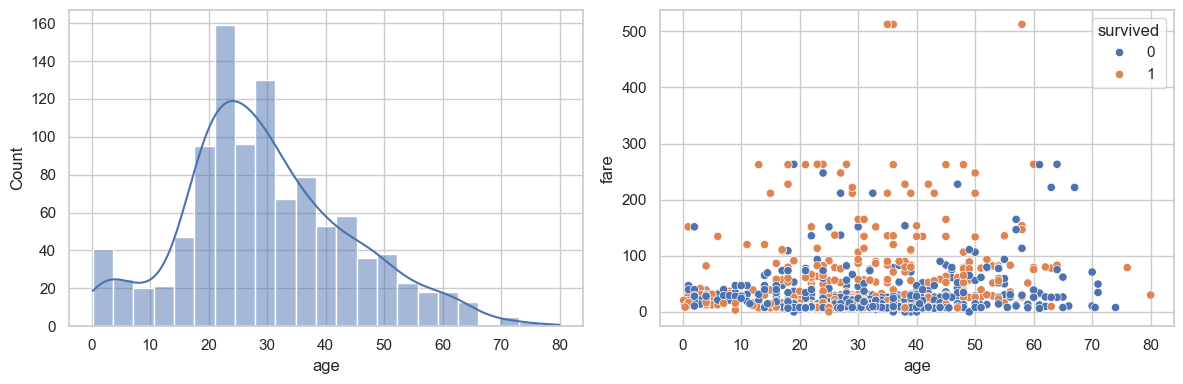

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['age'].dropna(), kde=True, ax=axes[0])
sns.scatterplot(data=df, x='age', y='fare', hue='survived', ax=axes[1])
plt.tight_layout()


## 3. Przygotowanie cech
To jest tylko wersja startowa. Zmień listę cech i sprawdź, czy wynik zaczyna wyglądać inaczej.


In [5]:
feature_columns = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[feature_columns].copy()

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features),
])

X_prepared = preprocessor.fit_transform(X)
X_prepared.shape


(1309, 10)

In [7]:
X_prepared

array([[-1.54609786, -0.03900549, -0.47908676, ...,  0.        ,
         0.        ,  1.        ],
       [-1.54609786, -2.21595217,  0.48128777, ...,  0.        ,
         0.        ,  1.        ],
       [-1.54609786, -2.13197749,  0.48128777, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.84191642, -0.23279919, -0.47908676, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.84191642, -0.19404045, -0.47908676, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.84191642, -0.03900549, -0.47908676, ...,  0.        ,
         0.        ,  1.        ]], shape=(1309, 10))

## 4. Klasteryzacja
Punkt wyjścia: `KMeans`. Zmień `n_clusters`, dodaj własną ocenę i sprawdź, czy da się sensownie opisać uzyskane grupy.


In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_prepared)

analysis_df = X.copy()
analysis_df['cluster'] = clusters
analysis_df.groupby('cluster').size()


cluster
0    792
1    174
2    343
dtype: int64

## 5. PCA na danych Titanic
`PCA` traktujemy jako prosty punkt startowy do wizualizacji klastrów.


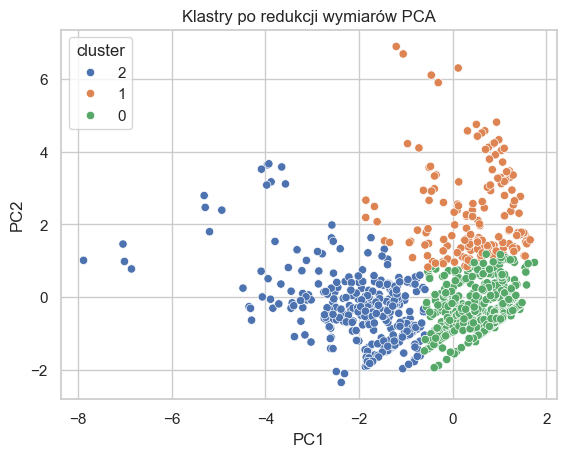

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prepared)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster': clusters.astype(str),
})

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster")
plt.title("Klastry po redukcji wymiarów PCA")
plt.show()


## Zadania aktywizujące
1. Usuń jedną cechę i oceń, czy podział na klastry się zmienia.
2. Dodaj własną wizualizację pomocną w EDA.
3. Sprawdź inną liczbę klastrów niż `3`.
4. Zastanów się, które cechy z danych studenckich mogłyby zastąpić cechy ze zbioru Titanic.
5. Jeśli chcesz pójść dalej, otwórz jeden z notebooków rozszerzających.


## Materiały rozszerzające dla chętnych
- `lab3-tsne-umap.ipynb` — przykłady `t-SNE` i opcjonalnie `UMAP` na zbiorze `digits`,
- `lab3-geopandas.ipynb` — krótki przykład wizualizacji geograficznej w `GeoPandas`,

Te notebooki nie są wymagane do realizacji części podstawowej, ale mogą być dobrym rozwinięciem dla osób, które chcą pójść krok dalej.
